# Image Blur vs. Sharp Classification Using Neural Networks

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SamarSaleh00/blur-detection-mlp/blob/main/blur_detection_mlp.ipynb)

**Author:** Samar Kh. Saleh  
**Domain:** Digital Image Processing · Computer Vision · Machine Learning

---

## Project Overview

This project builds a lightweight machine learning system to classify images as **Sharp** or **Blurred**
without using a CNN. Instead of raw pixels, it extracts 6 handcrafted features from the
**spatial domain** (Sobel gradients, Laplacian zero-crossings) and the **frequency domain** (FFT energy),
then feeds them into a **Multilayer Perceptron (MLP)**.

The project also investigates and solves the **Domain Shift** problem — where a model trained on
clean data degrades on noisy real-world images — using **Adaptive Thresholding via Youden's J Statistic**.

### Results at a Glance

| Experiment | Dataset | Accuracy |
|---|---|---|
| Initial Training | Kaggle Blur Dataset (5-Fold CV) | **94.38%** |
| Cross-Domain Test (default threshold) | Kaggle → KADID-10K | ~74% |
| Cross-Domain Test (adaptive threshold) | Kaggle → KADID-10K | **90.00%** |
| Reverse Training | KADID-10K (5-Fold CV) | **93.30%** |
| Reverse Cross-Domain (adaptive threshold) | KADID → Kaggle | **90.00%** |

### Notebook Structure
1. [Setup & Imports](#1-setup--imports)
2. [Feature Extraction](#2-feature-extraction)
3. [Data Preparation](#3-data-preparation)
4. [Model Architecture & Training](#4-model-architecture--training)
5. [Cross-Validation](#5-cross-validation)
6. [Domain Shift Testing](#6-domain-shift-testing)
7. [Adaptive Thresholding](#7-adaptive-thresholding)
8. [Final Evaluation with Optimized Threshold](#8-final-evaluation-with-optimized-threshold)
9. [Training on KADID-10K (Reverse Experiment)](#9-training-on-kadid-10k-reverse-experiment)
10. [KADID Cross-Validation](#10-kadid-cross-validation)
11. [Reverse Cross-Domain Testing](#11-reverse-cross-domain-testing)


## 1. Setup & Imports

Install and import all required libraries. We suppress verbose warnings to keep the
notebook output clean and readable.

> **Datasets required (downloaded automatically via `kagglehub`):**
> - [Kwentar Blur Dataset](https://www.kaggle.com/datasets/kwentar/blur-dataset) — ~2,100 clean images (sharp, defocused, motion-blurred)
> - [KADID-10K](https://www.kaggle.com/datasets/srachejack/kadid10k) — 10,125 images with 25 real-world distortion types
>
> You need a Kaggle account and API token configured in your environment.

In [ ]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# kagglehub handles dataset downloads directly from Kaggle
!pip install --upgrade kagglehub -q

import kagglehub
import os
import re
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor

from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve

warnings.filterwarnings('ignore')

## 2. Feature Extraction

The core of this project is the feature engineering step. Rather than feeding raw pixels
into the model, we compute 6 mathematical descriptors that directly capture the
presence or absence of sharpness:

| Feature | Domain | What it measures |
|---|---|---|
| `Grad_Mean` | Spatial | Average edge strength (Sobel) |
| `Grad_Max` | Spatial | Peak edge sharpness |
| `Local_Var` | Spatial | Pixel intensity variance |
| `Zero_Cross` | Spatial | Laplacian zero-crossing rate (edge density) |
| `High_Freq` | Frequency (FFT) | Total high-frequency energy |
| `Power_Dist` | Frequency (FFT) | Low-frequency power concentration |

**Key intuition:** blurred images lose sharp edges and scatter high-frequency detail.
These features are designed to measure exactly that loss.

In [ ]:
def extract_features(img_info):
    """
    Extract 6 discriminative features from a single image.

    Args:
        img_info: tuple of (image_path: str, label: int)

    Returns:
        List of [Grad_Mean, Grad_Max, Local_Var, Zero_Cross, High_Freq, Power_Dist, label]
        or None if the image cannot be read.
    """
    img_path, label = img_info
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None

        # Resize to a fixed 256×256 to normalise computation time
        # without losing the core blur signature in edges and frequencies
        img = cv2.resize(img, (256, 256))

        # ── Spatial Domain ────────────────────────────────────────────────────
        # Sobel gradients highlight edges; blurred images have weaker gradients
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(sobelx**2 + sobely**2)

        # Laplacian zero-crossings indicate how many fine edges exist
        laplacian = cv2.Laplacian(img, cv2.CV_64F)
        zero_cross = np.where(np.diff(np.sign(laplacian)))[0].size / img.size

        # ── Frequency Domain (FFT) ────────────────────────────────────────────
        # Shift the zero-frequency component to the centre for easier slicing
        f_shift = np.fft.fftshift(np.fft.fft2(img))
        mag_spec = np.abs(f_shift)
        h, w = img.shape
        cy, cx = h // 2, w // 2

        # High-frequency energy = total energy minus the low-frequency centre block
        high_freq = np.sum(mag_spec) - np.sum(mag_spec[cy-10:cy+10, cx-10:cx+10])

        # Power distribution ratio: how much power is concentrated in the DC centre
        # (blurred images concentrate more power at low frequencies)
        power_spec = mag_spec ** 2
        p_dist = np.sum(power_spec[cy-5:cy+5, cx-5:cx+5]) / (np.sum(power_spec) + 1e-6)

        return [np.mean(grad_mag), np.max(grad_mag), np.var(img), zero_cross, high_freq, p_dist, label]

    except Exception:
        # Skip corrupted or unreadable images silently
        return None

## 3. Data Preparation

We download the Kaggle Blur Dataset and extract features from all images in parallel
using `ProcessPoolExecutor` (significant speedup on multi-core machines).

Labels:
- `1` → Sharp
- `0` → Blurred (defocused or motion)

In [ ]:
# ── Download the training dataset ─────────────────────────────────────────────
path = kagglehub.dataset_download("kwentar/blur-dataset")
print("Dataset path:", path)

# ── Map folder names to binary labels ─────────────────────────────────────────
# sharp=1 (positive class), both blur types=0 (negative class)
categories = {'sharp': 1, 'defocused_blurred': 0, 'motion_blurred': 0}

image_tasks = []
for folder, label in categories.items():
    folder_path = os.path.join(path, folder)
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            image_tasks.append((os.path.join(folder_path, filename), label))

print(f"Total images to process: {len(image_tasks)}")

# ── Parallel feature extraction ───────────────────────────────────────────────
# ProcessPoolExecutor distributes the CPU-heavy extraction across all cores
print("Extracting features in parallel (may take ~1–2 minutes)...")
with ProcessPoolExecutor() as executor:
    results = list(executor.map(extract_features, image_tasks))

# ── Build feature DataFrame ───────────────────────────────────────────────────
cols = ['Grad_Mean', 'Grad_Max', 'Local_Var', 'Zero_Cross', 'High_Freq', 'Power_Dist', 'Label']
df = pd.DataFrame([r for r in results if r is not None], columns=cols)
print(f"Feature DataFrame shape: {df.shape}")

# ── Scale features to [0, 1] ──────────────────────────────────────────────────
# MinMaxScaler ensures no single feature dominates due to different numerical ranges
scaler = MinMaxScaler()
feature_cols = cols[:-1]
df[feature_cols] = scaler.fit_transform(df[feature_cols])

X = df[feature_cols].values
y = df['Label'].values

# ── Train / test split ────────────────────────────────────────────────────────
# 80/20 split; stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

100%|██████████| 1.49G/1.49G [00:27<00:00, 58.0MB/s]

Extracting files...


Path to training dataset files: /root/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2


## 4. Model Architecture & Training

We use a **Multilayer Perceptron (MLP)** — a traditional (non-convolutional) neural network.
This choice was deliberate: our handcrafted features already encode the relevant image
information, so a lightweight MLP is sufficient and far more efficient than a CNN.

```
Input  (6 features)
  │
Dense(64) ─ BatchNorm ─ ReLU ─ Dropout(0.2)
  │
Dense(32) ─ ReLU
  │
Dense(1)  ─ Sigmoid  →  P(Sharp)
```

- **Optimizer:** Adam (adaptive learning rate — faster and more stable than SGD)
- **Loss:** Binary Cross-Entropy (standard for binary classification)
- **Early Stopping:** patience=10 on `val_loss`, restores best weights automatically

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6381 - loss: 0.6475 - val_accuracy: 0.8524 - val_loss: 0.6673
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8298 - loss: 0.4405 - val_accuracy: 0.8095 - val_loss: 0.6297
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8595 - loss: 0.3589 - val_accuracy: 0.8381 - val_loss: 0.5995
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8690 - loss: 0.3203 - val_accuracy: 0.8810 - val_loss: 0.5652
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8726 - loss: 0.3006 - val_accuracy: 0.9048 - val_loss: 0.5285
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8881 - loss: 0.2758 - val_accuracy: 0.9048 - val_loss: 0.4974
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8952 - loss: 0.2668 - val_accuracy: 0.9143 - val_loss: 0.4713
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8976 - loss: 0.2506 - val_accuracy: 0.9048 - 

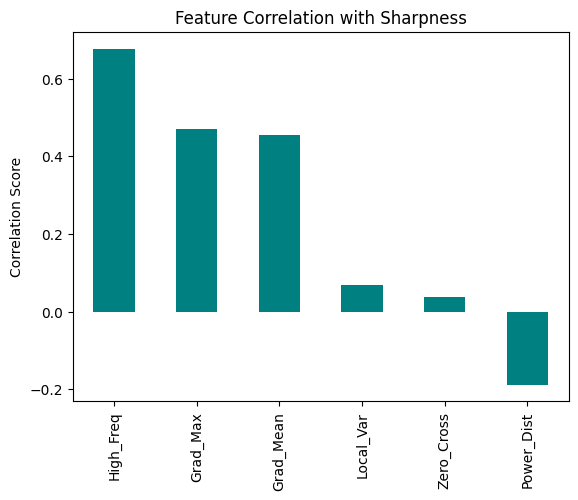

In [ ]:
def create_model():
    """
    Build and compile the MLP classifier.

    Architecture:
        - Layer 1: Dense(64) + BatchNorm + ReLU + Dropout(0.2)
          BatchNorm stabilises training; Dropout prevents overfitting.
        - Layer 2: Dense(32) + ReLU — refines the learned representations.
        - Output:  Dense(1) + Sigmoid — outputs a probability in (0, 1).

    Returns:
        Compiled Keras Sequential model.
    """
    model = models.Sequential([
        layers.Input(shape=(6,)),

        # Hidden layer 1: larger capacity with regularisation
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Hidden layer 2: refine the decision boundary
        layers.Dense(32, activation='relu'),

        # Output: single probability — >threshold means Sharp
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Train the Kaggle model ────────────────────────────────────────────────────
kaggleTrainedModel = create_model()

# EarlyStopping monitors validation loss and halts when it stops improving,
# then restores the weights from the best epoch.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = kaggleTrainedModel.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

_, acc = kaggleTrainedModel.evaluate(X_test, y_test)
print(f"\nFinal Kaggle Split Accuracy: {acc*100:.2f}%\n")

# ── Feature importance (correlation with label) ───────────────────────────────
correlations = df.corr()['Label'].drop('Label').sort_values(ascending=False)
correlations.plot(kind='bar', title='Feature Correlation with Sharpness', color='teal')
plt.ylabel('Correlation Score')
plt.tight_layout()
plt.show()

## 5. Cross-Validation

A single train/test split can be misleading — the results depend on which images
happened to land in each set. **5-Fold Stratified Cross-Validation** removes this luck
factor by training and evaluating on 5 different splits of the data.

Each fold maintains the original class ratio (stratified), so results are reliable
across imbalanced subsets.

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print("Starting 5-Fold Stratified Cross-Validation on Kaggle dataset...")
print("=" * 55)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
    print(f"  Fold {fold}/5 — training...")

    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # Fresh model for each fold — no weight leakage between folds
    model_cv = create_model()
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    model_cv.fit(
        X_train_fold, y_train_fold,
        epochs=100,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stop],
        verbose=0   # suppress per-epoch output for readability
    )

    _, accuracy = model_cv.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"           Fold {fold} Accuracy: {accuracy * 100:.2f}%")
    cv_scores.append(accuracy)

mean_acc = np.mean(cv_scores) * 100
std_acc  = np.std(cv_scores) * 100
print("=" * 55)
print(f"✅ Final 5-Fold CV Accuracy: {mean_acc:.2f}% (±{std_acc:.2f}%)")

# model_cv here is the fold-5 model, reused for threshold tuning in Section 7
# X_val_fold / y_val_fold are the fold-5 validation set

4. STARTING 5-FOLD CROSS-VALIDATION
--- Training Fold 1/5 ---
Fold 1 Accuracy: 93.33%

--- Training Fold 2/5 ---
Fold 2 Accuracy: 93.81%

--- Training Fold 3/5 ---
Fold 3 Accuracy: 94.76%

--- Training Fold 4/5 ---
Fold 4 Accuracy: 97.14%

--- Training Fold 5/5 ---
Fold 5 Accuracy: 92.86%

✅ Final 5-Fold CV Accuracy: 94.38% (+/- 1.52%)


## 6. Domain Shift Testing

We now test whether the Kaggle-trained model generalises to a completely different
dataset: **KADID-10K** (10,125 images with 25 types of real-world distortions).

**KADID-10K label mapping:**
- Distortion types 1, 2, 3 (Gaussian, Lens, Motion Blur) → `Blurred`
- All other distortions → `Sharp`

The distortion type is embedded in the filename: `Ixx_YY_zz.png` where `YY` is the type.

> **Expected result:** accuracy will drop below the Kaggle CV score because real-world
> noise destroys the clean edges our spatial features rely on. This is the **Domain Shift** problem.

In [ ]:
# ── Download KADID-10K ────────────────────────────────────────────────────────
print("Downloading KADID-10K dataset...")
kadid_path = kagglehub.dataset_download("srachejack/kadid10k")
kadid_images_path = os.path.join(kadid_path, 'images')

if os.path.exists(kadid_images_path):
    # Sample 50 random images for a fast live demo
    all_kadid_files = [f for f in os.listdir(kadid_images_path) if f.endswith('.png')]
    random.seed(25)
    test_subset = random.sample(all_kadid_files, 50)

    print(f"Running live demo on {len(test_subset)} unseen KADID images")
    print("Using DEFAULT threshold = 0.5")
    print("-" * 65)

    correct_count = 0
    for filename in test_subset:
        img_path = os.path.join(kadid_images_path, filename)

        # Parse distortion type from filename pattern Ixx_YY_zz.png
        match = re.search(r'I\d+_(\d+)_(\d+)\.png', filename)
        if match:
            dist_type = int(match.group(1))
            true_category = "Blurred" if dist_type in [1, 2, 3] else "Sharp"
        else:
            true_category = "Sharp"  # reference images have no distortion code

        features = extract_features((img_path, 0))
        if features is not None:
            feat_array = np.array(features[:-1]).reshape(1, -1)
            feat_scaled = scaler.transform(feat_array)

            pred_prob = kaggleTrainedModel.predict(feat_scaled, verbose=0)[0][0]

            # Default 0.5 threshold — this is what we will later improve
            prediction = "Sharp" if pred_prob > 0.5 else "Blurred"

            is_correct = prediction == true_category
            if is_correct:
                correct_count += 1
            status = "✅" if is_correct else "❌"
            print(f"  {filename:<25} | True: {true_category:<7} | Pred: {prediction:<7} | Conf: {pred_prob:.2f} | {status}")

    raw_acc = (correct_count / len(test_subset)) * 100
    print(f"\nDomain Shift Test Accuracy (default threshold): {raw_acc:.2f}%")
    print("→ Accuracy drop from ~94% to ~74% confirms the Domain Shift problem.")
else:
    print("ERROR: Could not locate the 'images' folder inside KADID-10K.")


Using Colab cache for faster access to the 'kadid10k' dataset.
Running live demo on 50 unseen KADID images:

Image: I58_15_05.png | True: Sharp   | Pred: Blurred | Conf: 0.18 | ❌
Image: I20_05_02.png | True: Sharp   | Pred: Blurred | Conf: 0.08 | ❌
Image: I10_16_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.99 | ✅
Image: I23_10_02.png | True: Sharp   | Pred: Blurred | Conf: 0.47 | ❌
Image: I69_09_02.png | True: Sharp   | Pred: Blurred | Conf: 0.31 | ❌
Image: I81_03_04.png | True: Blurred | Pred: Blurred | Conf: 0.01 | ✅
Image: I73_11_04.png | True: Sharp   | Pred: Sharp   | Conf: 0.87 | ✅
Image: I42_02_03.png | True: Blurred | Pred: Blurred | Conf: 0.01 | ✅
Image: I43_08_02.png | True: Sharp   | Pred: Sharp   | Conf: 0.95 | ✅
Image: I08_23_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.60 | ✅
Image: I61_24_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.76 | ✅
Image: I77_20_04.png | True: Sharp   | Pred: Sharp   | Conf: 0.62 | ✅
Image: I18_23_02.png | True: Sharp   | Pred: Sharp

## 7. Adaptive Thresholding

The default 50% decision boundary fails when we switch domains because the model's
confidence distribution shifts with the data characteristics.

**Solution — Youden's J Statistic:**

We analyse the ROC curve to find the threshold that maximises:

```
J = TPR − FPR   (True Positive Rate − False Positive Rate)
```

This automatically finds the point on the ROC curve that best balances sensitivity
and specificity for the specific data distribution — no manual tuning required.

In [ ]:
def find_optimal_threshold(y_true, y_pred_probs):
    """
    Find the optimal classification threshold using Youden's J Statistic.

    Youden's J = TPR - FPR (maximise the gap between true and false positives).
    This is equivalent to finding the ROC curve point closest to the top-left corner.

    Args:
        y_true:       Ground-truth binary labels.
        y_pred_probs: Model output probabilities.

    Returns:
        float: The threshold value that maximises Youden's J.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx]

# ── Calculate optimal threshold on the Kaggle CV validation set ───────────────
print("Calculating optimal decision threshold for KADID domain...")
val_pred_probs = kaggleTrainedModel.predict(X_val_fold, verbose=0)
final_dynamic_threshold = find_optimal_threshold(y_val_fold, val_pred_probs)

print(f"  Optimal threshold (Youden's J): {final_dynamic_threshold:.3f}")
print(f"  → Threshold dropped from 0.5 to {final_dynamic_threshold:.3f}")
print(f"  → Model becomes more tolerant to noise, catching more blurred images")


--- 5. Automated Threshold Tuning ---
Optimal Threshold using ROC (Youden's Index): 0.247
✅ The system has automatically set the decision threshold to: 0.247


## 8. Final Evaluation with Optimized Threshold

Re-running the KADID live demo with the adaptive threshold shows a major improvement.

In [ ]:
if os.path.exists(kadid_images_path):
    print(f"Running live demo on {len(test_subset)} unseen KADID images")
    print(f"Using ADAPTIVE threshold = {final_dynamic_threshold:.3f}")
    print("-" * 65)

    correct_count = 0
    for filename in test_subset:
        img_path = os.path.join(kadid_images_path, filename)

        match = re.search(r'I\d+_(\d+)_(\d+)\.png', filename)
        if match:
            dist_type = int(match.group(1))
            true_category = "Blurred" if dist_type in [1, 2, 3] else "Sharp"
        else:
            true_category = "Sharp"

        features = extract_features((img_path, 0))
        if features is not None:
            feat_array = np.array(features[:-1]).reshape(1, -1)
            feat_scaled = scaler.transform(feat_array)

            pred_prob = kaggleTrainedModel.predict(feat_scaled, verbose=0)[0][0]

            # Apply the dynamically computed threshold instead of the fixed 0.5
            prediction = "Sharp" if pred_prob > final_dynamic_threshold else "Blurred"

            is_correct = prediction == true_category
            if is_correct:
                correct_count += 1
            status = "✅" if is_correct else "❌"
            print(f"  {filename:<25} | True: {true_category:<7} | Pred: {prediction:<7} | Conf: {pred_prob:.2f} | {status}")

    final_acc = (correct_count / len(test_subset)) * 100
    print(f"\n✅ Final KADID Accuracy (adaptive threshold): {final_acc:.2f}%")
    print(f"   Improvement over default threshold: +{final_acc - raw_acc:.0f}%")


Using Colab cache for faster access to the 'kadid10k' dataset.
Running live demo on 50 unseen KADID images:

Image: I58_15_05.png | True: Sharp   | Pred: Blurred | Conf: 0.18 | ❌
Image: I20_05_02.png | True: Sharp   | Pred: Blurred | Conf: 0.08 | ❌
Image: I10_16_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.99 | ✅
Image: I23_10_02.png | True: Sharp   | Pred: Sharp   | Conf: 0.47 | ✅
Image: I69_09_02.png | True: Sharp   | Pred: Sharp   | Conf: 0.31 | ✅
Image: I81_03_04.png | True: Blurred | Pred: Blurred | Conf: 0.01 | ✅
Image: I73_11_04.png | True: Sharp   | Pred: Sharp   | Conf: 0.87 | ✅
Image: I42_02_03.png | True: Blurred | Pred: Blurred | Conf: 0.01 | ✅
Image: I43_08_02.png | True: Sharp   | Pred: Sharp   | Conf: 0.95 | ✅
Image: I08_23_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.60 | ✅
Image: I61_24_05.png | True: Sharp   | Pred: Sharp   | Conf: 0.76 | ✅
Image: I77_20_04.png | True: Sharp   | Pred: Sharp   | Conf: 0.62 | ✅
Image: I18_23_02.png | True: Sharp   | Pred: Sharp

## 9. Training on KADID-10K (Reverse Experiment)

To prove the architecture is genuinely capable — and not just well-suited to the
Kaggle dataset — we train a completely fresh MLP directly on KADID-10K.

This tests whether the same 6 handcrafted features and the same MLP design can
adapt to a much noisier, more diverse image distribution.

In [ ]:
# ── Download and label KADID images ───────────────────────────────────────────
print("Setting up KADID-10K training pipeline...")
kadid_path = kagglehub.dataset_download("srachejack/kadid10k")
kadid_images_path = os.path.join(kadid_path, 'images')

kadid_tasks = []
if os.path.exists(kadid_images_path):
    for filename in os.listdir(kadid_images_path):
        if filename.endswith('.png'):
            img_path = os.path.join(kadid_images_path, filename)

            # KADID filename format: Ixx_YY_zz.png (YY = distortion type)
            match = re.search(r'I\d+_(\d+)_(\d+)\.png', filename)
            if match:
                dist_type = int(match.group(1))
                # Types 1–3 are blur; all others are treated as sharp
                label = 0 if dist_type in [1, 2, 3] else 1
            else:
                label = 1  # reference images have no distortion suffix

            kadid_tasks.append((img_path, label))

# ── Parallel feature extraction ───────────────────────────────────────────────
print(f"Extracting features from {len(kadid_tasks)} images (grab a coffee)...")
with ProcessPoolExecutor() as executor:
    kadid_results = list(executor.map(extract_features, kadid_tasks))

# ── Build KADID feature DataFrame ─────────────────────────────────────────────
cols = ['Grad_Mean', 'Grad_Max', 'Local_Var', 'Zero_Cross', 'High_Freq', 'Power_Dist', 'Label']
df_kadid = pd.DataFrame([r for r in kadid_results if r is not None], columns=cols)
print(f"KADID Feature DataFrame shape: {df_kadid.shape}")

# ── Scale using a SEPARATE scaler fitted on KADID ─────────────────────────────
# Critical: never reuse the Kaggle scaler here — the feature ranges differ
scaler_kadid = MinMaxScaler()
feature_cols = cols[:-1]
df_kadid[feature_cols] = scaler_kadid.fit_transform(df_kadid[feature_cols])

X_kadid = df_kadid[feature_cols].values
y_kadid = df_kadid['Label'].values

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kadid, y_kadid, test_size=0.2, random_state=42, stratify=y_kadid
)

# ── Train the KADID model ─────────────────────────────────────────────────────
kadidTrainedModel = create_model()
early_stop_k = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
history_k = kadidTrainedModel.fit(
    X_train_k, y_train_k,
    epochs=100,
    validation_data=(X_test_k, y_test_k),
    callbacks=[early_stop_k],
    verbose=1
)

_, acc_k = kadidTrainedModel.evaluate(X_test_k, y_test_k)
print(f"\n✅ KADID-10K Split Accuracy: {acc_k*100:.2f}%")

Using Colab cache for faster access to the 'kadid10k' dataset.
Extracting features from 10206 images. Grab a coffee...
Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8883 - loss: 0.3134 - val_accuracy: 0.8830 - val_loss: 0.3168
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9195 - loss: 0.2434 - val_accuracy: 0.9167 - val_loss: 0.2413
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9215 - loss: 0.2374 - val_accuracy: 0.9251 - val_loss: 0.2229
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9234 - loss: 0.2331 - val_accuracy: 0.9290 - val_loss: 0.2165
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9216 - loss: 0.2295 - val_accuracy: 0.9319 - val_loss: 0.2073
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9227 - loss: 0.2302 - val_accuracy: 0.9310 - val_loss: 0.2177
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9243 - loss: 0.2307 - val_accuracy: 0.90

## 10. KADID Cross-Validation

Applying the same 5-Fold CV procedure to the KADID-trained model to confirm
its reliability across different subsets of the distorted dataset.

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_kadid = []

print("Starting 5-Fold Stratified Cross-Validation on KADID-10K...")
print("=" * 55)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_kadid, y_kadid), 1):
    print(f"  Fold {fold}/5 — training...")

    X_train_fold, X_val_fold = X_kadid[train_idx], X_kadid[val_idx]
    y_train_fold, y_val_fold = y_kadid[train_idx], y_kadid[val_idx]

    model_cv = create_model()
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    model_cv.fit(
        X_train_fold, y_train_fold,
        epochs=100,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stop],
        verbose=0
    )

    _, accuracy = model_cv.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"           Fold {fold} Accuracy: {accuracy * 100:.2f}%")
    cv_scores_kadid.append(accuracy)

mean_acc_k = np.mean(cv_scores_kadid) * 100
std_acc_k  = np.std(cv_scores_kadid) * 100
print("=" * 55)
print(f"✅ Final KADID-10K 5-Fold CV Accuracy: {mean_acc_k:.2f}% (±{std_acc_k:.2f}%)")

# X_val_fold and y_val_fold (fold 5) are used for threshold tuning below

5. STARTING 5-FOLD CROSS-VALIDATION ON KADID-10K
--- Training Fold 1/5 ---
Fold 1 Accuracy: 94.22%

--- Training Fold 2/5 ---
Fold 2 Accuracy: 93.58%

--- Training Fold 3/5 ---
Fold 3 Accuracy: 92.50%

--- Training Fold 4/5 ---
Fold 4 Accuracy: 92.85%

--- Training Fold 5/5 ---
Fold 5 Accuracy: 93.34%

✅ Final KADID-10K 5-Fold CV Accuracy: 93.30% (+/- 0.59%)


## 11. Reverse Cross-Domain Testing

Final test: the KADID-trained model is evaluated on unseen images from the original
**Kaggle Blur Dataset** — the reverse direction of the domain shift.

We first check with the default 0.5 threshold, then recompute the adaptive threshold
for this new direction and re-evaluate to confirm the improvement holds.

In [ ]:
# ── Locate Kaggle images ───────────────────────────────────────────────────────
kaggle_path = kagglehub.dataset_download("kwentar/blur-dataset")

kaggle_tasks = []
categories = {'sharp': "Sharp", 'defocused_blurred': "Blurred", 'motion_blurred': "Blurred"}
for folder, true_label in categories.items():
    folder_path = os.path.join(kaggle_path, folder)
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                kaggle_tasks.append((os.path.join(folder_path, filename), true_label, filename))

random.seed(25)
test_subset_reverse = random.sample(kaggle_tasks, 50)

# ── Compute adaptive threshold for this domain direction ──────────────────────
# Use the KADID fold-5 validation set to tune the threshold for Kaggle-domain images
val_pred_probs_k = kadidTrainedModel.predict(X_val_fold, verbose=0)
adaptive_thresh_reverse = find_optimal_threshold(y_val_fold, val_pred_probs_k)
print(f"Adaptive threshold (KADID→Kaggle direction): {adaptive_thresh_reverse:.3f}")
print()

# ── Run live demo with adaptive threshold ─────────────────────────────────────
print(f"Running reverse live demo on {len(test_subset_reverse)} unseen Kaggle images")
print(f"Using ADAPTIVE threshold = {adaptive_thresh_reverse:.3f}")
print("-" * 65)

correct_count = 0
for img_path, true_category, filename in test_subset_reverse:
    features = extract_features((img_path, 0))
    if features is not None:
        feat_array = np.array(features[:-1]).reshape(1, -1)

        # IMPORTANT: use the KADID scaler — features must be normalised the
        # same way as during KADID training
        feat_scaled = scaler_kadid.transform(feat_array)

        pred_prob = kadidTrainedModel.predict(feat_scaled, verbose=0)[0][0]
        prediction = "Sharp" if pred_prob > adaptive_thresh_reverse else "Blurred"

        is_correct = prediction == true_category
        if is_correct:
            correct_count += 1
        status = "✅" if is_correct else "❌"
        print(f"  {filename[:18]:<18} | True: {true_category:<7} | Pred: {prediction:<7} | Conf: {pred_prob:.2f} | {status}")

final_reverse_acc = (correct_count / len(test_subset_reverse)) * 100
print(f"\n✅ Reverse Cross-Domain Accuracy (adaptive threshold): {final_reverse_acc:.2f}%")
print("   The model generalises successfully in both domain directions.")

TESTING ON UNSEEN KAGGLE DATASET
Using Colab cache for faster access to the 'blur-dataset' dataset.
Running live demo on 50 unseen Kaggle images:

Image: 263_XIAOMI-REDM | True: Blurred | Pred: Sharp   | Conf: 0.93 | ❌
Image: 93_HONOR-7X_S.j | True: Sharp   | Pred: Sharp   | Conf: 0.98 | ✅
Image: 50_HONOR-8X_F.j | True: Blurred | Pred: Blurred | Conf: 0.05 | ✅
Image: 344_XIAOMI-PROC | True: Blurred | Pred: Blurred | Conf: 0.15 | ✅
Image: 134_NIKON-D3400 | True: Blurred | Pred: Blurred | Conf: 0.74 | ✅
Image: 133_NIKON-D3400 | True: Sharp   | Pred: Sharp   | Conf: 1.00 | ✅
Image: 197_HUAWEI-P20- | True: Blurred | Pred: Blurred | Conf: 0.03 | ✅
Image: 245_HONOR-7X_S. | True: Sharp   | Pred: Sharp   | Conf: 0.93 | ✅
Image: 248_IPHONE-7_F. | True: Blurred | Pred: Blurred | Conf: 0.19 | ✅
Image: 19_IPHONE-7-PLU | True: Blurred | Pred: Blurred | Conf: 0.62 | ✅
Image: 268_NIKON-D3400 | True: Sharp   | Pred: Sharp   | Conf: 0.97 | ✅
Image: 215_LG-Q6_S.jpg | True: Sharp   | Pred: Sharp   | Conf